# Business problem
Can we predict whether a loan applicant should be approved or rejected — based on their financial profile and credit history — 
so the bank can reduce default risk while avoiding unfair rejections?

Data|set link - https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset 

# This Dataset is trained on Logistic Regression + Decision Tree

# 1. Load and explore data

In [2]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [5]:
# check for nulls
df.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [6]:
df.describe().map('{:,.2f}'.format)

# The describe shows a brief description about all the numeric columns.
# It speaks, what is the Mean, STD, min and max value
# How many datapoints are below 25%, below median and below 75%

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,"4,269.00","4,269.00","4,269.00","4,269.00","4,269.00","4,269.00","4,269.00","4,269.00","4,269.00","4,269.00"
mean,"2,135.00",2.50,"5,059,123.92","15,133,450.46",10.90,599.94,"7,472,616.54","4,973,155.31","15,126,305.93","4,976,692.43"
std,"1,232.50",1.70,"2,806,839.83","9,043,362.98",5.71,172.43,"6,503,636.59","4,388,966.09","9,103,753.67","3,250,185.31"
min,1.00,0.00,"200,000.00","300,000.00",2.00,300.00,"-100,000.00",0.00,"300,000.00",0.00
25%,"1,068.00",1.00,"2,700,000.00","7,700,000.00",6.00,453.00,"2,200,000.00","1,300,000.00","7,500,000.00","2,300,000.00"
50%,"2,135.00",3.00,"5,100,000.00","14,500,000.00",10.00,600.00,"5,600,000.00","3,700,000.00","14,600,000.00","4,600,000.00"
75%,"3,202.00",4.00,"7,500,000.00","21,500,000.00",16.00,748.00,"11,300,000.00","7,600,000.00","21,700,000.00","7,100,000.00"
max,"4,269.00",5.00,"9,900,000.00","39,500,000.00",20.00,900.00,"29,100,000.00","19,400,000.00","39,200,000.00","14,700,000.00"


In [7]:
# get count of duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [9]:
#filtering column names
df.columns = df.columns.str.strip()

In [10]:
# Filtering string spaces and title case
string_cols = df.select_dtypes(include=['object']).columns

df[string_cols] = df[string_cols].apply(lambda x: x.str.strip().str.title())

# 2. EDA

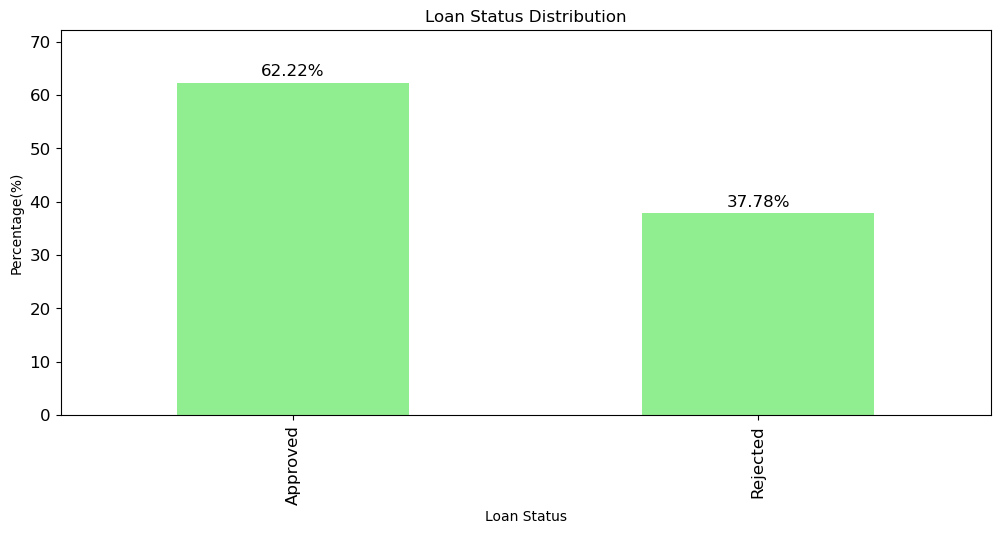

In [11]:
# Get the loan distribution - Get the % of approved and rejected

loan_distribution = df['loan_status'].value_counts(normalize=True)*100

ax = loan_distribution.plot(kind='bar', figsize=(12,5), fontsize=12, color='lightgreen')

# % sign on top of bar
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=12)

# padding so the labels don't get cut off at the top
ax.set_ylim(0, loan_distribution.max() + 10)

ax.set_xlabel("Loan Status")
ax.set_ylabel("Percentage(%)")
ax.set_title("Loan Status Distribution")
plt.show()


# This Plot shows:
# 62.22% Loans are approved & 37.78% are rejected overall in the dataset

In [12]:
# how many are graduated + self employed & Not Graduate + self employee get the relation of approval vs rejected

pd.crosstab(
    index=[df['education'], df['self_employed']],
    columns=df['loan_status'],
    normalize='index'
).round(2) * 100

# This means Education has no impact on Loan

# The Approved & Rejected numbers are in Percentage

loan_status                 Approved  Rejected
education    self_employed                    
Graduate     No                 63.0      37.0
             Yes                62.0      38.0
Not Graduate No                 62.0      38.0
             Yes                62.0      38.0

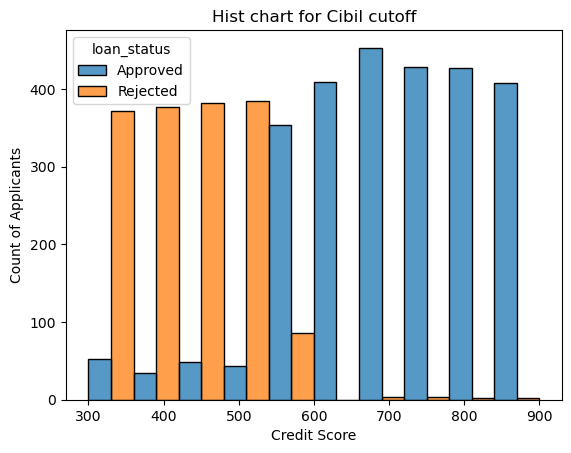

In [13]:
# Find the cutoff for CIBIL score. Below which value the loans are rejeceted

sns.histplot(data=df, x=df['cibil_score'], hue='loan_status', bins=10,multiple='dodge')
plt.title("Hist chart for Cibil cutoff")
plt.xlabel('Credit Score')
plt.ylabel('Count of Applicants')
plt.show()

# This shows the cutoff is near to 600 score. But there are some cases where loan is approved with less cutoff and rejeceted where the cutoff is more
# Also, this Shows "cibil score" influences the apporval decision more

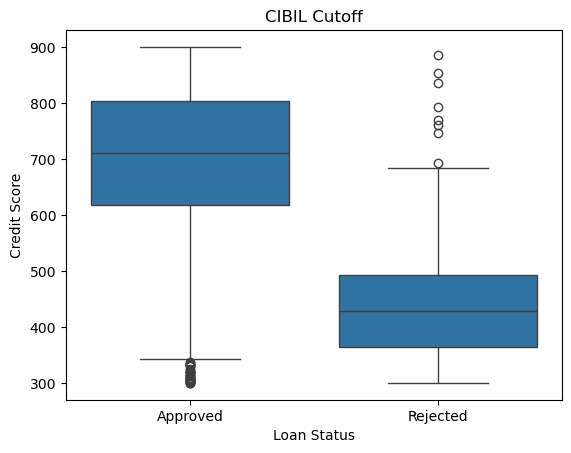

In [14]:
# Finding the same realtion using Boxplot
sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('CIBIL Cutoff')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.show()

# The "o" are outliers. There are some extreme cases where the loan is approved even the credit score is less than 350, and loan is rejected even when credit score is above 600

# So, close to 600 credit score is the cutoff for the bank

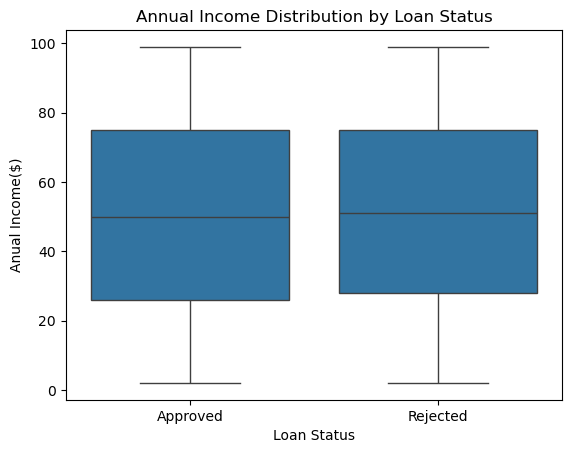

In [15]:
# Annual Income distribution with loan status

sns.boxplot(data=df, x='loan_status', y=df['income_annum']/100000)
plt.title('Annual Income Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel("Anual Income($)")
plt.show()

# This shows that Income dosen't matter while taking the loan. There are people with same income whose loan is rejected

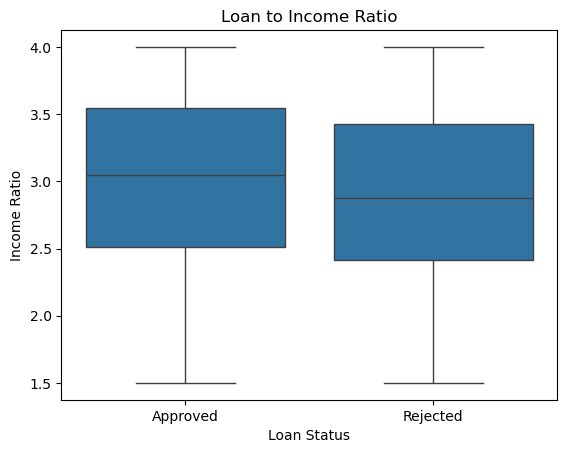

In [16]:
# Loan-to-income-ratio - new column

df['lti_ratio'] = df['loan_amount'] / df['income_annum']

sns.boxplot(data=df, x='loan_status', y='lti_ratio')
plt.title("Loan to Income Ratio")
plt.xlabel('Loan Status')
plt.ylabel('Income Ratio')
plt.show()

# This boxplot shows even when your Income Ratio is high, still the Loan can be rejected or approved. Which means the Income Ratio dose not influece the Loan decisions

In [17]:
# If a person defaults, can bank recover the money from their assets?
# Adding all the assests and comparing with loan amount

df['total_assets'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']

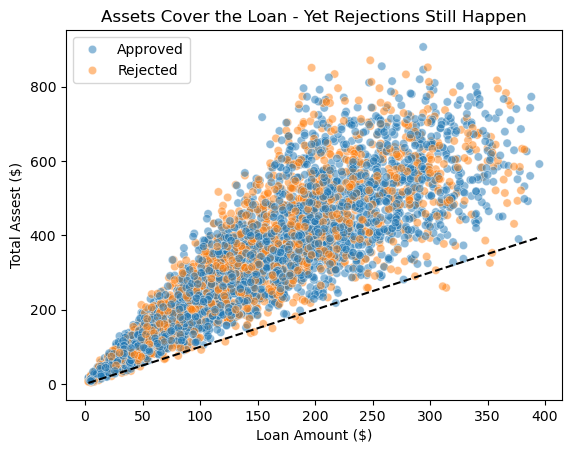

In [18]:
min_loan_amount = df['loan_amount'].min() / 100000
max_loan_amount = df['loan_amount'].max() / 100000

sns.scatterplot(data=df, x=df['loan_amount'] / 100000, y=df['total_assets'] / 100000, hue=df['loan_status'], alpha=0.5 )
plt.xlabel('Loan Amount ($)')
plt.ylabel('Total Assest ($)')
plt.title('Assets Cover the Loan - Yet Rejections Still Happen')
plt.legend()
plt.plot([min_loan_amount, max_loan_amount], [min_loan_amount, max_loan_amount], color='black', linestyle='--')

# This plot shows that, Almost everyone are above the dashed line, which means both groups have the "Assets" greater than the loan amount. So, bank can recover if Default

# This shows Assests coverage does not determine the approval 

In [19]:
# Dropping columns which don't add much information 
# Some columns are clubbed into single column

df_copy = df.copy()
df_copy.drop(columns=['loan_id','residential_assets_value','commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'], inplace=True)
df_copy

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,lti_ratio,total_assets
0,2,Graduate,No,9600000,29900000,12,778,Approved,3.114583,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,2.975610,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,3.263736,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,3.743902,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,2.469388,55000000
...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,Rejected,2.300000,7400000
4265,0,Not Graduate,Yes,3300000,11300000,20,559,Approved,3.424242,20000000
4266,2,Not Graduate,No,6500000,23900000,18,457,Rejected,3.676923,39000000
4267,1,Not Graduate,No,4100000,12800000,8,780,Approved,3.121951,28800000


In [20]:
# Add new Column Asset Coverage
df_copy['asset_coverage'] = (df['total_assets'] / df['loan_amount'])
df_copy

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,lti_ratio,total_assets,asset_coverage
0,2,Graduate,No,9600000,29900000,12,778,Approved,3.114583,50700000,1.695652
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,2.975610,17000000,1.393443
2,3,Graduate,No,9100000,29700000,20,506,Rejected,3.263736,57700000,1.942761
3,3,Graduate,No,8200000,30700000,8,467,Rejected,3.743902,52700000,1.716612
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,2.469388,55000000,2.272727
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,Rejected,2.300000,7400000,3.217391
4265,0,Not Graduate,Yes,3300000,11300000,20,559,Approved,3.424242,20000000,1.769912
4266,2,Not Graduate,No,6500000,23900000,18,457,Rejected,3.676923,39000000,1.631799
4267,1,Not Graduate,No,4100000,12800000,8,780,Approved,3.121951,28800000,2.250000


In [21]:
# Convert Object columns which has 2 values to 1 and 0

df_copy['loan_status'] = df_copy['loan_status'].map({'Approved':1, 'Rejected':0})
df_copy['education'] = df_copy['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_copy['self_employed'] = df_copy['self_employed'].map({'Yes':1, 'No': 0})

In [22]:
numeric_cols = df_copy.select_dtypes(include=['float64','int64']).columns
numeric_cols

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'loan_status', 'lti_ratio',
       'total_assets', 'asset_coverage'],
      dtype='object')

In [23]:
correlation = df_copy[numeric_cols].corr()['loan_status'].sort_values(ascending=False)
correlation

loan_status         1.000000
cibil_score         0.770518
lti_ratio           0.087726
loan_amount         0.016150
education           0.004918
self_employed       0.000345
total_assets       -0.011281
income_annum       -0.015189
no_of_dependents   -0.018114
asset_coverage     -0.050070
loan_term          -0.113036
Name: loan_status, dtype: float64

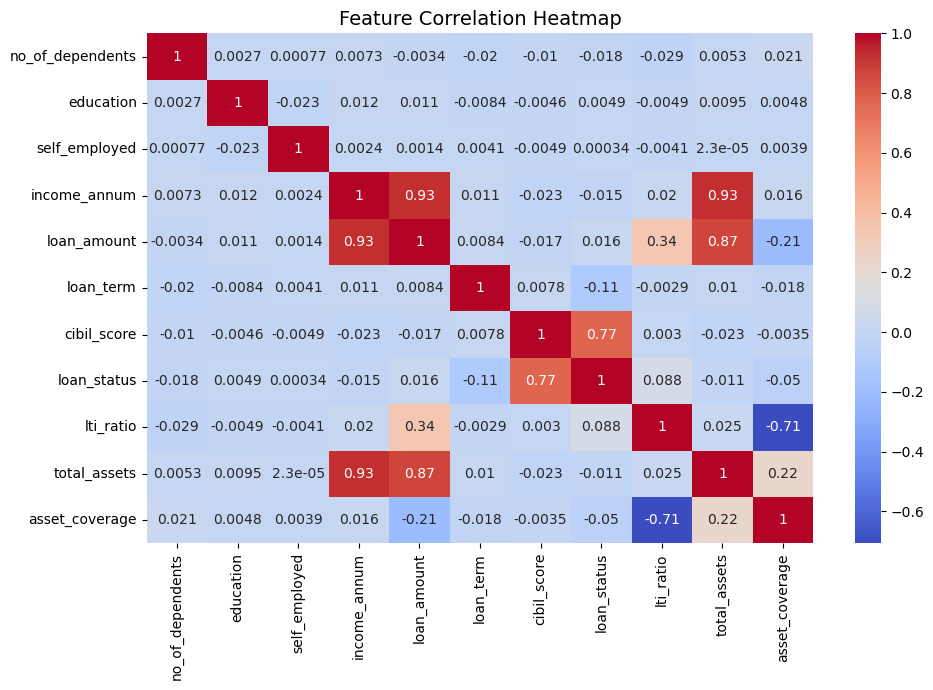

In [24]:
# heat map of all correlation

plt.figure(figsize=(10,7))
correaltion = df_copy[numeric_cols].corr()
sns.heatmap(correaltion, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Compute Variance Inflation Factor (VIF) with each feature for Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df_copy[['cibil_score', 'lti_ratio', 'loan_amount', 'education', 'self_employed', 'total_assets', 'income_annum', 'no_of_dependents', 'asset_coverage', 'loan_term']]

# Constant for accurate regression calculation
X_with_constant = add_constant(X)

# Dataframe for vif results
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range (1,X_with_constant.shape[1])]
vif_data


,Feature,VIF
0,cibil_score,1.001111
1,lti_ratio,7.229695
2,loan_amount,27.995444
3,education,1.000934
4,self_employed,1.000781
5,total_assets,23.613785
6,income_annum,45.062116
7,no_of_dependents,1.001470
8,asset_coverage,6.227455
9,loan_term,1.003059


In [26]:
# dropping columns with high multicollinearity (VIF > 5)

# dropping - income_annum & loan_amount as "lti_ratio" covers it
# can drop total_assets, as ratio is covers in asset_coverage column

df_copy.drop(columns=['income_annum', 'loan_amount', 'total_assets'], inplace=True)


In [27]:
df_copy

,no_of_dependents,education,self_employed,loan_term,cibil_score,loan_status,lti_ratio,asset_coverage
0,2,1,0,12,778,1,3.114583,1.695652
1,0,0,1,8,417,0,2.975610,1.393443
2,3,1,0,20,506,0,3.263736,1.942761
3,3,1,0,8,467,0,3.743902,1.716612
4,5,0,1,20,382,0,2.469388,2.272727
...,...,...,...,...,...,...,...,...
4264,5,1,1,12,317,0,2.300000,3.217391
4265,0,0,1,20,559,1,3.424242,1.769912
4266,2,0,0,18,457,0,3.676923,1.631799
4267,1,0,0,8,780,1,3.121951,2.250000


# 3. Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_copy.drop(['loan_status'], axis=1)
y = df_copy['loan_status']

# Divide the data into train test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

# Define which columns to scale
cols_to_scale = ['cibil_score', 'lti_ratio', 'asset_coverage', 'loan_term']
cols_as_is = ['education', 'self_employed', 'no_of_dependents']

# Apply stdscaler - Fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = scaler.transform(X_test[cols_to_scale])

# Convert scaled array to dataframes
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=cols_to_scale, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=cols_to_scale, index=X_test.index)

# Combined scaled + binary columns
X_train_final = pd.concat([X_train_scaled_df, X_train[cols_as_is]], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test[cols_as_is]], axis=1)

In [29]:
X_train_final.head()

,cibil_score,lti_ratio,asset_coverage,loan_term,education,self_employed,no_of_dependents
1675,-0.187401,1.332392,-1.159249,-0.860003,0,0,5
1164,0.637397,0.924324,0.194850,0.188894,0,1,0
192,0.474761,1.064183,0.235829,-0.510371,1,0,1
910,0.892968,-0.532772,0.714030,1.237791,1,1,2
567,-0.925072,1.190055,-0.619647,0.188894,1,1,5


# 4. Build the Logistic Regression model

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_final, y_train)

print("Training completed")


Training completed


In [31]:
# The model gives a Class and a probability 
y_pred = model.predict(X_test_final)            # this gives prediction weather class 1 or 0
y_proba = model.predict_proba(X_test_final)     # probability of how sure model is

print("First 5 Predictions: ", y_pred[:5])
print("First 5 Probabilities: ", y_proba[:5].round(3))


# Predict tells the answer
# predict proba tells how sure the model is

First 5 Predictions:  [0 1 0 1 1]
First 5 Probabilities:  [[0.963 0.037]
 [0.169 0.831]
 [0.964 0.036]
 [0.037 0.963]
 [0.011 0.989]]


# 5. Evalutaion

In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [33]:
# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy Score:-",acc)


Accuracy Score:- 0.9004683840749415


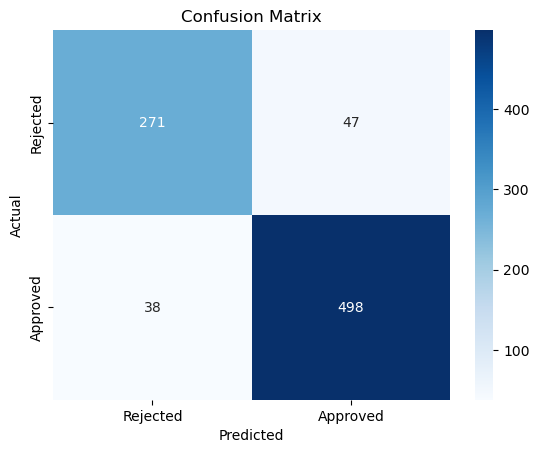

In [34]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
# Precision score
precision = precision_score(y_test, y_pred)

print("Precision Score", round(precision, 3))

Precision Score 0.914


In [36]:
# Recall score
recall = recall_score(y_test, y_pred)

print("Recall Score", round(recall,3))

Recall Score 0.929


In [37]:
# F1 score

f1 = f1_score(y_test, y_pred)

print("F1- Score", round(f1, 3))

F1- Score 0.921


In [38]:
# Classification report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       318
           1       0.91      0.93      0.92       536

    accuracy                           0.90       854
   macro avg       0.90      0.89      0.89       854
weighted avg       0.90      0.90      0.90       854



In [39]:
# Confusion Matrix distribution

# As this information is about bank which is crucial.

# 1. False Positive - 47 - Acutal was Rejected but model said Approved - This will affect the Bank, because if the customer was not qualified for the loan and due to model's mistake it was approved. Then, if customer was not able to payback the loan, then bank would bear the loss. So, we have to focus here as well

# 2. False Negative - 38 - Actual was Approved but Model said Rejected - This will affect the Bank, because if customer was qualified and due to model's error the loan was rejected. And if the customer was in urgent need for the loan, the customer could take an action on the bank due to model's mistake. Bank could deal with reputation loss. So, this parameter is also important

# Using Decision Tree on the same dataset

In [40]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,lti_ratio,total_assets
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,3.114583,50700000
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,2.975610,17000000
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,3.263736,57700000
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,3.743902,52700000
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,2.469388,55000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,2.300000,7400000
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,3.424242,20000000
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,3.676923,39000000
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,3.121951,28800000


In [41]:
# Creating a copy of dataframe into new variable & dropping columns which don't add much information

df_new = df.copy()
df_new.drop(columns=['loan_id','residential_assets_value','commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'], inplace=True)
df_new

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,lti_ratio,total_assets
0,2,Graduate,No,9600000,29900000,12,778,Approved,3.114583,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,2.975610,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,3.263736,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,3.743902,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,2.469388,55000000
...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,Rejected,2.300000,7400000
4265,0,Not Graduate,Yes,3300000,11300000,20,559,Approved,3.424242,20000000
4266,2,Not Graduate,No,6500000,23900000,18,457,Rejected,3.676923,39000000
4267,1,Not Graduate,No,4100000,12800000,8,780,Approved,3.121951,28800000


In [42]:
# Add new Column Asset Coverage
df_new['asset_coverage'] = (df_new['total_assets'] / df_new['loan_amount'])
df_new

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,lti_ratio,total_assets,asset_coverage
0,2,Graduate,No,9600000,29900000,12,778,Approved,3.114583,50700000,1.695652
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,2.975610,17000000,1.393443
2,3,Graduate,No,9100000,29700000,20,506,Rejected,3.263736,57700000,1.942761
3,3,Graduate,No,8200000,30700000,8,467,Rejected,3.743902,52700000,1.716612
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,2.469388,55000000,2.272727
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,Rejected,2.300000,7400000,3.217391
4265,0,Not Graduate,Yes,3300000,11300000,20,559,Approved,3.424242,20000000,1.769912
4266,2,Not Graduate,No,6500000,23900000,18,457,Rejected,3.676923,39000000,1.631799
4267,1,Not Graduate,No,4100000,12800000,8,780,Approved,3.121951,28800000,2.250000


In [43]:
# Scaling is not required for Decision Tree (loan_status, education, self_employed) These column dosen't need scaling

# As Correlation between the columns is already calculated -- Skipping the correlation + VIF check here


In [44]:
# Directly dropping the columns with high multicollinearity (VIF > 5)
# dropping - income_annum & loan_amount as "lti_ratio" covers it
# can drop total_assets, as ratio is covers in asset_coverage column

df_new.drop(columns=['income_annum', 'loan_amount', 'total_assets'], inplace=True)

In [45]:
# Convert Object columns which has 2 values to 1 and 0

df_new['loan_status'] = df_new['loan_status'].map({'Approved':1, 'Rejected':0})
df_new['education'] = df_new['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_new['self_employed'] = df_new['self_employed'].map({'Yes':1, 'No': 0})

In [46]:
df_new.dtypes

no_of_dependents      int64
education             int64
self_employed         int64
loan_term             int64
cibil_score           int64
loan_status           int64
lti_ratio           float64
asset_coverage      float64
dtype: object

# Train - Test split

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df_new.drop(['loan_status'], axis=1)
y = df_new['loan_status']

# Divide the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # stratify=y keeps the class balance same in train and test

print("Train rows: ", X_train.shape[0], "| Test rows: ", X_test.shape[0])

Train rows:  3415 | Test rows:  854


# Build the Model

In [48]:
model = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=42) # by-default the model uses gini
model.fit(X_train, y_train)

print("Train Accracy:", round(model.score(X_train, y_train), 3))  # Accuracy on train data
print("Test Accracy:", round(model.score(X_test, y_test), 3))     # Accuracy on test data

Train Accracy: 0.959
Test Accracy: 0.968


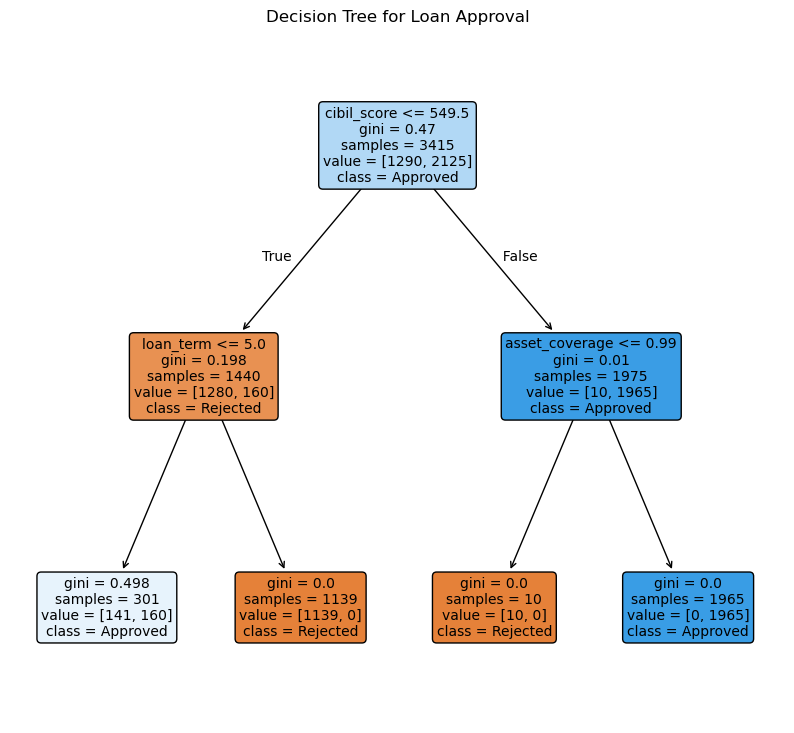

In [49]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 9))
plot_tree(model, feature_names=list(X.columns), class_names=['Rejected', 'Approved'],    # Class_name follow order[0,1,2,..].. as in Loan-status Rejected=0, Approved=1
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree for Loan Approval')
plt.show()

In [50]:
from sklearn.tree import export_text

print(export_text(model, feature_names=list(X.columns)))

|--- cibil_score <= 549.50
|   |--- loan_term <= 5.00
|   |   |--- class: 1
|   |--- loan_term >  5.00
|   |   |--- class: 0
|--- cibil_score >  549.50
|   |--- asset_coverage <= 0.99
|   |   |--- class: 0
|   |--- asset_coverage >  0.99
|   |   |--- class: 1



- Low CIBIL + short loan term  → Approved  (small risk, bank accepts)
- Low CIBIL + long loan term   → Rejected  (too risky, bank says no)
- High CIBIL + low assets      → Rejected  (good score but can't cover loan)
- High CIBIL + high assets     → Approved  (ideal borrower, bank approves)

- Accuracy for Logistic Regression is 90%

- Accuracy of Decision Tree is 96%

- Decision tree has performed good on the loan-approval dataset

# How to choose the best Max depth

- Try range of depth values

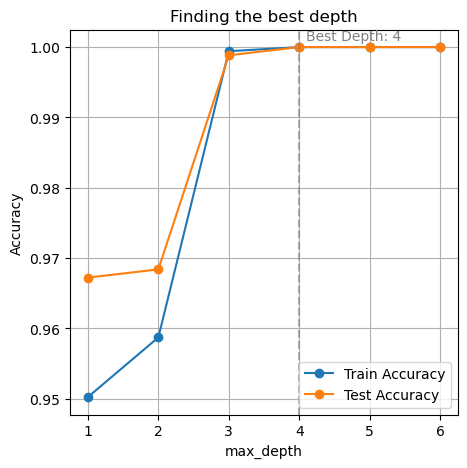

In [64]:
depths = range(1,7)

train_acc = []
test_acc = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(5,5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

best_depth = list(depths)[int(np.argmax(test_acc))]  # get the best depth

plt.axvline(best_depth, color='gray', linestyle='--', alpha=0.6)
plt.text(best_depth + 0.1,1.001, f'Best Depth: {best_depth}',color='gray')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Finding the best depth')
plt.grid()
plt.legend()
plt.show()


In [ ]:
# The graph shows the best depth as 4 for the model, but at that level the train, test accuracy is closer to 1 which is bad for the model

# So, the depth=2 for this model